1: Data set


In [38]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# ── Load and Prepare Coursera Dataset ───────────────────────────────
df_courses = pd.read_csv('/content/coursea_data.csv')

# Clean enrolled numbers
def parse_enrolled(val):
    try:
        val = str(val).lower().strip()
        if 'k' in val:
            return float(val.replace('k', '')) * 1000
        elif 'm' in val:
            return float(val.replace('m', '')) * 1000000
        else:
            return float(val) if val.replace('.', '').isdigit() else 0
    except:
        return 0

df_courses['enrolled_clean'] = df_courses['course_students_enrolled'].apply(parse_enrolled)

# Drop rows with missing values
df_courses = df_courses.dropna(subset=['course_difficulty', 'course_rating'])
df_courses = df_courses[df_courses['enrolled_clean'] > 0]

print(f"Dataset loaded: {len(df_courses)} courses")
print(df_courses[['course_title', 'enrolled_clean', 'course_difficulty']].head(3))

# Encode difficulty labels
le = LabelEncoder()
df_courses['difficulty_encoded'] = le.fit_transform(df_courses['course_difficulty'])

# Features and target
X_courses = df_courses[['course_rating', 'enrolled_clean']].values
y_courses = df_courses['difficulty_encoded'].values

# Train classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_courses, y_courses)

# Difficulty map back to numeric 1-10 scale
difficulty_label_to_score = {
    'Beginner': 3,
    'Mixed': 5,
    'Intermediate': 7,
    'Advanced': 10
}


print("\nDifficulty classifier ready.")
print(f"Classes: {le.classes_}")

Dataset loaded: 891 courses
                                        course_title  enrolled_clean  \
0  (ISC)² Systems Security Certified Practitioner...          5300.0   
1  A Crash Course in Causality:  Inferring Causal...         17000.0   
2                     A Crash Course in Data Science        130000.0   

  course_difficulty  
0          Beginner  
1      Intermediate  
2             Mixed  

Difficulty classifier ready.
Classes: ['Advanced' 'Beginner' 'Intermediate' 'Mixed']


In [39]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

def generate_dataset(num_samples=1000):
    num_subjects = np.random.randint(1, 7, num_samples)          # 1–6 subjects
    days_until_exam = np.random.randint(1, 31, num_samples)      # 1–30 days
    difficulty = np.random.randint(1, 11, num_samples)           # 1–10 difficulty
    available_hours = np.random.randint(1, 13, num_samples)      # 1–12 hrs/day

    # Output: recommended study hours per subject per day
    recommended_hours = (difficulty * 0.5 + (1 / days_until_exam) * 10 + available_hours * 0.3) / num_subjects # This is a general forumla.
    recommended_hours = np.clip(recommended_hours, 0.5, 12)  # keep it realistic


    # possible_difficulty_dataset => Course ID,Course rating, Course Difficulty
    # amount of students

    # Beginner = 1
    # Intermediate = 2
    # Mixed = 3
    # Advanced = 4

    #dataset_difficulty = {134 : possible_difficulty_dataset}

    df = pd.DataFrame({
        'num_subjects': num_subjects,
        'days_until_exam': days_until_exam,
        'difficulty': difficulty,
        'available_hours': available_hours,
        'recommended_hours': recommended_hours
    })
    return df

df = generate_dataset(1000)
print(df.head())
print(df.describe())

   num_subjects  days_until_exam  difficulty  available_hours  \
0             4               22           2                8   
1             5               21           2                9   
2             3                6           4                4   
3             5                6           3                6   
4             5               23           4                9   

   recommended_hours  
0           0.963636  
1           0.835238  
2           1.622222  
3           0.993333  
4           1.026957  
       num_subjects  days_until_exam   difficulty  available_hours  \
count   1000.000000      1000.000000  1000.000000      1000.000000   
mean       3.457000        15.403000     5.412000         6.477000   
std        1.714377         8.814663     2.842593         3.488788   
min        1.000000         1.000000     1.000000         1.000000   
25%        2.000000         8.000000     3.000000         3.000000   
50%        4.000000        15.000000     5.000000  

2. Preprocess Data

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df[['num_subjects', 'days_until_exam', 'difficulty', 'available_hours']].values
y = df['recommended_hours'].values

# Split into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 800
Testing samples: 200


3: MLP Model

In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(4,)),  # Input layer → Hidden layer 1
        Dense(32, activation='relu'),                     # Hidden layer 2
        Dense(1)                                          # Output layer (regression)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_90 (Dense)                │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_92 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

4. Trainin Data

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 7.3911 - mae: 1.9118 - val_loss: 7.0531 - val_mae: 1.7993
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3383 - mae: 1.3030 - val_loss: 3.9049 - val_mae: 1.2560
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.2263 - mae: 0.8961 - val_loss: 2.0121 - val_mae: 0.8679
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.2711 - mae: 0.7229 - val_loss: 1.1931 - val_mae: 0.7341
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8867 - mae: 0.6624 - val_loss: 1.0368 - val_mae: 0.6860
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7610 - mae: 0.6090 - val_loss: 0.9363 - val_mae: 0.6417
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6804 - mae: 0.5595 - val_loss: 0.8787 - val_mae: 0.6082
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6263 - mae: 0.5256 - val_loss: 0.8211 - val_mae: 0.5699
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.587

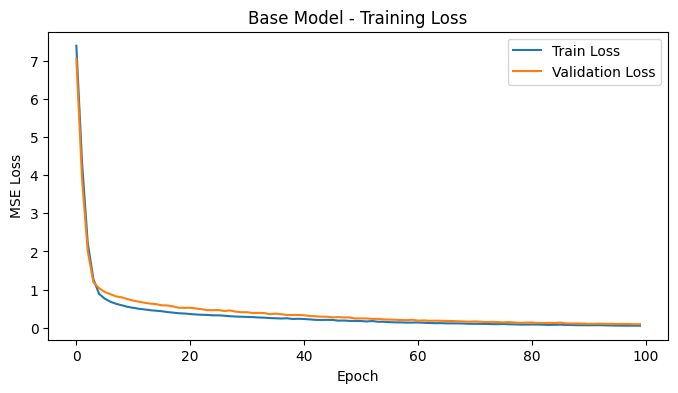

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0558 - mae: 0.1344 
Test MSE: 0.0558 | Test MAE: 0.1344


In [42]:
import matplotlib.pyplot as plt

# Train the base model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Base Model - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# Evaluate on test set
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MSE: {test_loss:.4f} | Test MAE: {test_mae:.4f}")

5. 3 experiments

In [43]:
# ── Experiment 1: Vary number of epochs ──────────────────────────────
results_epochs = {}
for epochs in [50, 100, 200]:
    m = build_model()
    h = m.fit(X_train, y_train, epochs=epochs, batch_size=32,
              validation_split=0.2, verbose=0)
    loss, mae = m.evaluate(X_test, y_test, verbose=0)
    results_epochs[epochs] = {'mse': loss, 'mae': mae}
    print(f"Epochs={epochs} → Test MSE: {loss:.4f}, MAE: {mae:.4f}")

# ── Experiment 2: Vary neuron sizes ──────────────────────────────────
architectures = [(32, 16), (64, 32), (128, 64)]
results_arch = {}
for (n1, n2) in architectures:
    m = Sequential([
        Dense(n1, activation='relu', input_shape=(4,)),
        Dense(n2, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    m.fit(X_train, y_train, epochs=100, batch_size=32,
          validation_split=0.2, verbose=0)
    loss, mae = m.evaluate(X_test, y_test, verbose=0)
    results_arch[f"{n1}/{n2}"] = {'mse': loss, 'mae': mae}
    print(f"Architecture={n1}/{n2} → Test MSE: {loss:.4f}, MAE: {mae:.4f}")

# ── Experiment 3: Vary dataset size ──────────────────────────────────
results_size = {}
for size in [500, 1000, 2000]:
    df_temp = generate_dataset(size)
    X_temp = df_temp[['num_subjects', 'days_until_exam', 'difficulty', 'available_hours']].values
    y_temp = df_temp['recommended_hours'].values
    X_tr, X_te, y_tr, y_te = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr)
    X_te = sc.transform(X_te)
    m = build_model()
    m.fit(X_tr, y_tr, epochs=100, batch_size=32, validation_split=0.2, verbose=0)
    loss, mae = m.evaluate(X_te, y_te, verbose=0)
    results_size[size] = {'mse': loss, 'mae': mae}
    print(f"Dataset size={size} → Test MSE: {loss:.4f}, MAE: {mae:.4f}")

Epochs=50 → Test MSE: 0.1276, MAE: 0.2628
Epochs=100 → Test MSE: 0.0592, MAE: 0.1446
Epochs=200 → Test MSE: 0.0189, MAE: 0.0939
Architecture=32/16 → Test MSE: 0.1128, MAE: 0.2299
Architecture=64/32 → Test MSE: 0.0528, MAE: 0.1421
Architecture=128/64 → Test MSE: 0.0238, MAE: 0.0882


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset size=500 → Test MSE: 0.4283, MAE: 0.3676


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset size=1000 → Test MSE: 0.1136, MAE: 0.1897


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Dataset size=2000 → Test MSE: 0.1236, MAE: 0.1126


Plotting resulsts

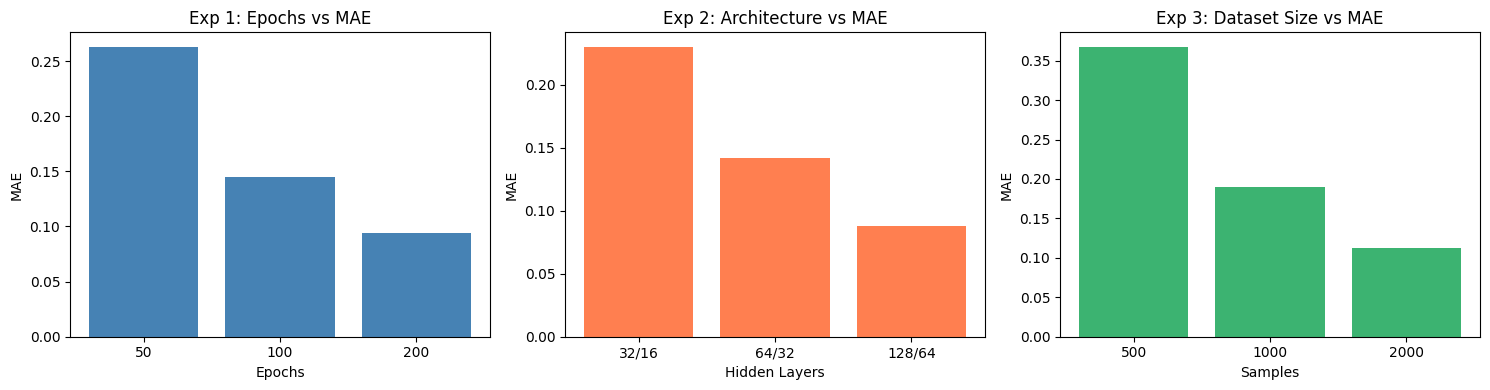

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Experiment 1 - Epochs
axes[0].bar([str(k) for k in results_epochs.keys()],
            [v['mae'] for v in results_epochs.values()], color='steelblue')
axes[0].set_title('Exp 1: Epochs vs MAE')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('MAE')

# Experiment 2 - Architecture
axes[1].bar(list(results_arch.keys()),
            [v['mae'] for v in results_arch.values()], color='coral')
axes[1].set_title('Exp 2: Architecture vs MAE')
axes[1].set_xlabel('Hidden Layers')
axes[1].set_ylabel('MAE')

# Experiment 3 - Dataset size
axes[2].bar([str(k) for k in results_size.keys()],
            [v['mae'] for v in results_size.values()], color='mediumseagreen')
axes[2].set_title('Exp 3: Dataset Size vs MAE')
axes[2].set_xlabel('Samples')
axes[2].set_ylabel('MAE')

plt.tight_layout()
plt.show()

In [45]:
import numpy as np

# Your actual inputs
my_input = np.array([[3, 7, 8, 5]])  # [num_subjects, days_until_exam, difficulty, available_hours]
my_input_scaled = scaler.transform(my_input)

prediction = model.predict(my_input_scaled)
hours_per_subject_per_day = prediction[0][0]
num_subjects = my_input[0][0]
days = my_input[0][1]
total_hours = hours_per_subject_per_day * num_subjects * days

print(f"Hours per subject per day: {hours_per_subject_per_day:.2f}")
print(f"Total hours per day: {(hours_per_subject_per_day * num_subjects):.2f}")
print(f"Total hours over {days} days: {total_hours:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Hours per subject per day: 2.11
Total hours per day: 6.34
Total hours over 7 days: 44.41


In [46]:
# ── User Input ──────────────────────────────────────────────────────
print("=== Optimal Study Scheduler ===\n")

num_subjects = int(input("How many subjects are you studying? "))
subjects = []
difficulties = []

for i in range(num_subjects):
    name = input(f"Enter name of subject {i+1}: ")
    diff = get_difficulty_from_dataset(name)
    subjects.append(name)
    difficulties.append(diff)

days_until_exam = int(input("\nHow many days until your exam? "))
available_hours = int(input("How many hours are you available to study per day? "))

if available_hours < 6:
    print("\n Warning: You may need more available hours per day to cover all subjects fully.\n")

# Step 1: Get MLP prediction
import numpy as np
avg_difficulty = sum(difficulties) / len(difficulties)
user_input = np.array([[num_subjects, days_until_exam, avg_difficulty, available_hours]])
user_input_scaled = scaler.transform(user_input)
predicted = model.predict(user_input_scaled)
hours_per_subject_per_day = round(float(predicted[0][0]), 1)
print(f"\nMLP recommends {hours_per_subject_per_day} hrs/subject/day\n")

# Step 2: Define weekly time blocks
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
time_slots = ['9am-11am', '11am-1pm', '2pm-4pm', '4pm-6pm', '6pm-8pm']

# Step 3: Track hours needed weighted by difficulty
total_difficulty = sum(difficulties)
hours_needed = {
    subjects[i]: round((difficulties[i] / total_difficulty) * hours_per_subject_per_day * num_subjects * days_until_exam, 1)
    for i in range(num_subjects)
}

print("Hours assigned per subject based on difficulty:")
for s, h in hours_needed.items():
    print(f"   {s}: {h} hrs total")
print()

schedule = {day: [] for day in days}

# Step 4: Greedy assignment
for day in days:
    slots_used = 0
    max_slots = available_hours // 2
    block_count = 0
    break_inserted = False

    while slots_used < max_slots and slots_used < len(time_slots):
        if block_count == 2 and not break_inserted:
            schedule[day].append(f"{time_slots[slots_used]} → Break")
            slots_used += 1
            break_inserted = True
            continue

        remaining = [(s, h) for s, h in hours_needed.items() if h > 0]
        if not remaining:
            break

        subject = max(remaining, key=lambda x: x[1])[0]
        if slots_used >= len(time_slots):
            break
        slot = time_slots[slots_used]
        schedule[day].append(f"{slot} → {subject}")
        hours_needed[subject] = round(max(0, hours_needed[subject] - 2), 1)
        slots_used += 1
        block_count += 1

# Step 5: Print the schedule
print("=" * 40)
print("       WEEKLY STUDY SCHEDULE")
print("=" * 40)
for day in days:
    print(f"\n {day}:")
    if schedule[day]:
        for entry in schedule[day]:
            print(f"   {entry}")
    else:
        print("    Free day")

# Step 6: Coverage report
print("\n" + "=" * 40)
print("Hours remaining per subject:")
for subject, hrs in hours_needed.items():
    status = " Covered" if hrs <= 0 else f" {hrs:.1f} hrs still needed"
    print(f"   {subject}: {status}")

=== Optimal Study Scheduler ===

How many subjects are you studying? 4
Enter name of subject 1: math
   Matched: 'Data Science Math Skills'
   Predicted difficulty: Beginner -> 3/10
Enter name of subject 2: science
   Matched: 'A Crash Course in Data Science'
   Predicted difficulty: Mixed -> 5/10
Enter name of subject 3: history
   Matched: 'The Modern World, Part One: Global History from 1760 to 1910'
   Predicted difficulty: Mixed -> 5/10
Enter name of subject 4: english
   Matched: 'Academic English: Writing'
   Predicted difficulty: Beginner -> 3/10

How many days until your exam? 7
How many hours are you available to study per day? 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step

MLP recommends 1.3 hrs/subject/day

Hours assigned per subject based on difficulty:
   math: 6.8 hrs total
   science: 11.4 hrs total
   history: 11.4 hrs total
   english: 6.8 hrs total

       WEEKLY STUDY SCHEDULE

 Monday:
   9am-11am → science
   11am-1pm → history
   2pm-4pm → Break

 Tuesday:
   9am-11am 

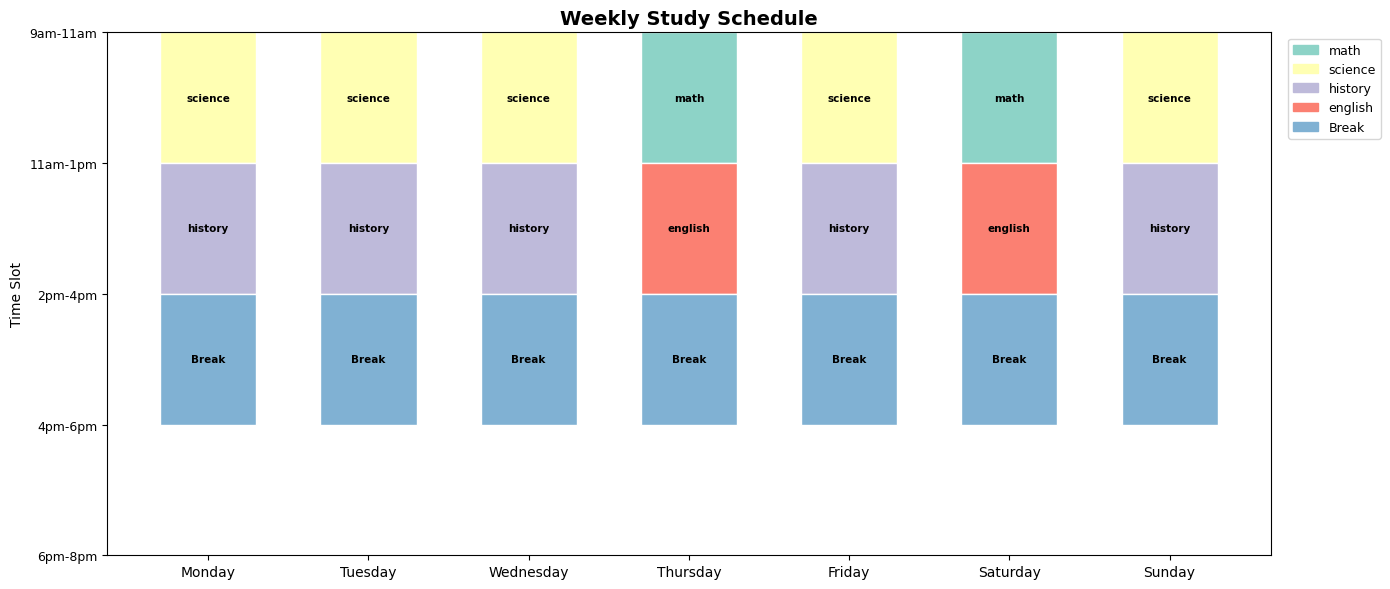

       DAILY STRESS SCORE
Monday       1.43  ██
Tuesday      1.43  ██
Wednesday    1.43  ██
Thursday     0.86  █
Friday       1.43  ██
Saturday     0.86  █
Sunday       1.43  ██


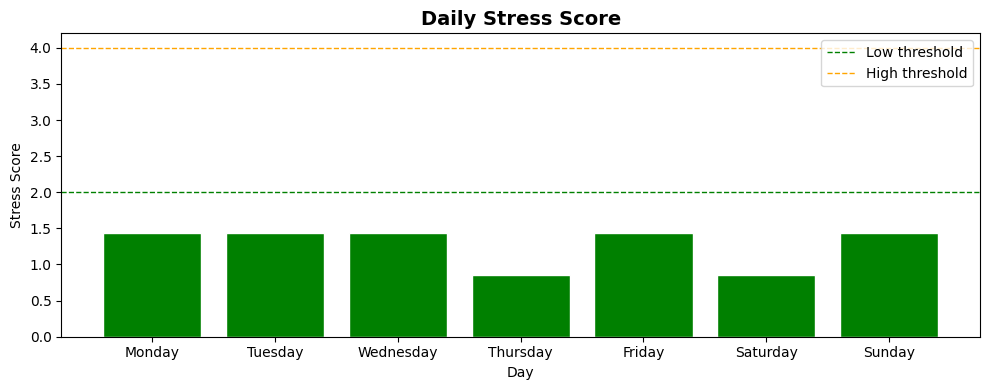

In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Visual Schedule ──────────────────────────────────────────────────

# Assign a color to each subject and break
all_labels = subjects + ['Break']
colors = plt.cm.Set3.colors[:len(all_labels)]
color_map = {label: colors[i] for i, label in enumerate(all_labels)}

fig, ax = plt.subplots(figsize=(14, 6))

slot_positions = {
    '9am-11am': 0,
    '11am-1pm': 1,
    '2pm-4pm': 2,
    '4pm-6pm': 3,
    '6pm-8pm': 4
}

day_positions = {day: i for i, day in enumerate(days)}

for day, entries in schedule.items():
    for entry in entries:
        slot, label = entry.split(' → ')
        label = label.strip()
        x = day_positions[day]
        y = slot_positions.get(slot, 0)
        color = color_map.get(label, 'lightgrey')
        ax.bar(x, 1, bottom=y, color=color, edgecolor='white', width=0.6)
        ax.text(x, y + 0.5, label, ha='center', va='center', fontsize=7.5, fontweight='bold')

# Formatting
ax.set_xticks(range(len(days)))
ax.set_xticklabels(days, fontsize=10)
ax.set_yticks(range(len(slot_positions)))
ax.set_yticklabels(list(slot_positions.keys()), fontsize=9)
ax.set_ylabel('Time Slot')
ax.set_title('Weekly Study Schedule', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Legend
patches = [mpatches.Patch(color=color_map[l], label=l) for l in all_labels]
ax.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

# ── Daily Stress Score ──────────────────────────────────────────────

# Stress per block = difficulty of subject / days_until_exam
subject_difficulty = {subjects[i]: difficulties[i] for i in range(num_subjects)}

daily_stress = {}
for day, entries in schedule.items():
    stress = 0
    for entry in entries:
        _, label = entry.split(' → ')
        label = label.strip()
        if label != 'Break':
            diff = subject_difficulty.get(label, 0)
            stress += diff / days_until_exam
    daily_stress[day] = round(stress, 2)

# Print stress scores
print("=" * 40)
print("       DAILY STRESS SCORE")
print("=" * 40)
for day, score in daily_stress.items():
    if score == 0:
        bar = "Rest day"
    else:
        bar = "█" * int(score * 2)
    print(f"{day:<12} {score:.2f}  {bar}")

# Plot stress scores
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['green' if s < 2 else 'orange' if s < 4 else 'red' for s in daily_stress.values()]
ax.bar(daily_stress.keys(), daily_stress.values(), color=colors, edgecolor='white')
ax.set_title('Daily Stress Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Stress Score')
ax.axhline(y=2, color='green', linestyle='--', linewidth=1, label='Low threshold')
ax.axhline(y=4, color='orange', linestyle='--', linewidth=1, label='High threshold')
ax.legend()
plt.tight_layout()
plt.show()